<a href="https://colab.research.google.com/github/shaimathamer/Mapping_Test/blob/main/Senegal_NDVI_Vegetation_Evolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem
The objective is to build a small, reproducible remote-sensing pipeline to evaluate how vegetation conditions changed between May 2025 and Nov 2025 in a selected agricultural area in Senegal using Sentinel-2 Level-2A imagery.bold text

Vegetation is monitored with the **Normalized Difference Vegetation Index (NDVI)**:

\[
NDVI = \frac{NIR - Red}{NIR + Red}
\]

For Sentinel-2, **B04** is the Red band and **B08** is the Near-Infrared (NIR) band. Healthy vegetation typically absorbs more red light and reflects more near-infrared light, so greener vegetation usually produces higher NDVI values.this notebook calculates NDVI directly from the raw Sentinel-2 bands. This makes the workflow reproducible and allows us to validate the input data before interpreting the result.The data **AOI** from Copernicus site.


### Pipeline


1. Upload Sentinel-2 B04 and B08 TIFF files for any number of dates.
2. Detect the acquisition date and band automatically from each filename.
3. Check that each date contains both B04 and B08.
4. Validate raster dimensions, coordinate system, spatial alignment, and pixel values.
5. Treat zero-valued pixels as invalid/no-data for this exercise.
6. Calculate NDVI for every valid date.
7. Summarize the NDVI distribution using mean, median, minimum, maximum, and percentiles.
8. Visualize an NDVI map for every observation using the same scale.
9. Plot mean and median NDVI through time.
10. Compare the first and last observations to create a vegetation-change map.
11. Optionally focus on positive NDVI values as a simple vegetation-oriented view


### Approach

To make comparisons meaningful, the images should cover the same Area of Interest (AOI), and the selected scenes should be visually checked to avoid major cloud contamination over the study area.

Pixels with a value of zero in either B04 or B08 are treated as invalid/no-data and are not used when calculating NDVI.

The number of dates is not fixed. With only two dates, the analysis describes change between two moments. With more observations, the same pipeline gives a more informative vegetation time series.

I approached this task as a vegetation change-detection problem. My idea was that changes in vegetation over time can be observed using satellite images, so I used Sentinel-2 data from two different dates and compared the NDVI values over the same study area.


During data checking, I found that some pixels contained a value of zero, especially in the Nov image. I considered these pixels as invalid or no-data pixels and excluded them from the NDVI calculation so that they would not affect the results.

In this analysis, I used only two dates. Therefore, the result represents vegetation change between May and Nov 2025, rather than a complete description of the vegetation throughout the whole growing season.

I also used positive NDVI values (NDVI > 0) as a simple way to focus more on vegetated areas. However, this is only an initial assumption and does not guarantee that all selected pixels correspond to crops. A more complete analysis could use a crop mask, water mask, land-cover data, or additional Sentinel-2 bands to separate agricultural vegetation from other land-cover types.

The objective is to build a **reusable pipeline** rather than code written only for May and Nov. A user can upload any number of Sentinel-2 observations, provided that every date has both a B04 and a B08 TIFF file. The notebook automatically detects the acquisition dates, groups the matching bands, validates the data, calculates NDVI, produces maps and statistics, and analyses vegetation change through time.

Install and import libraries

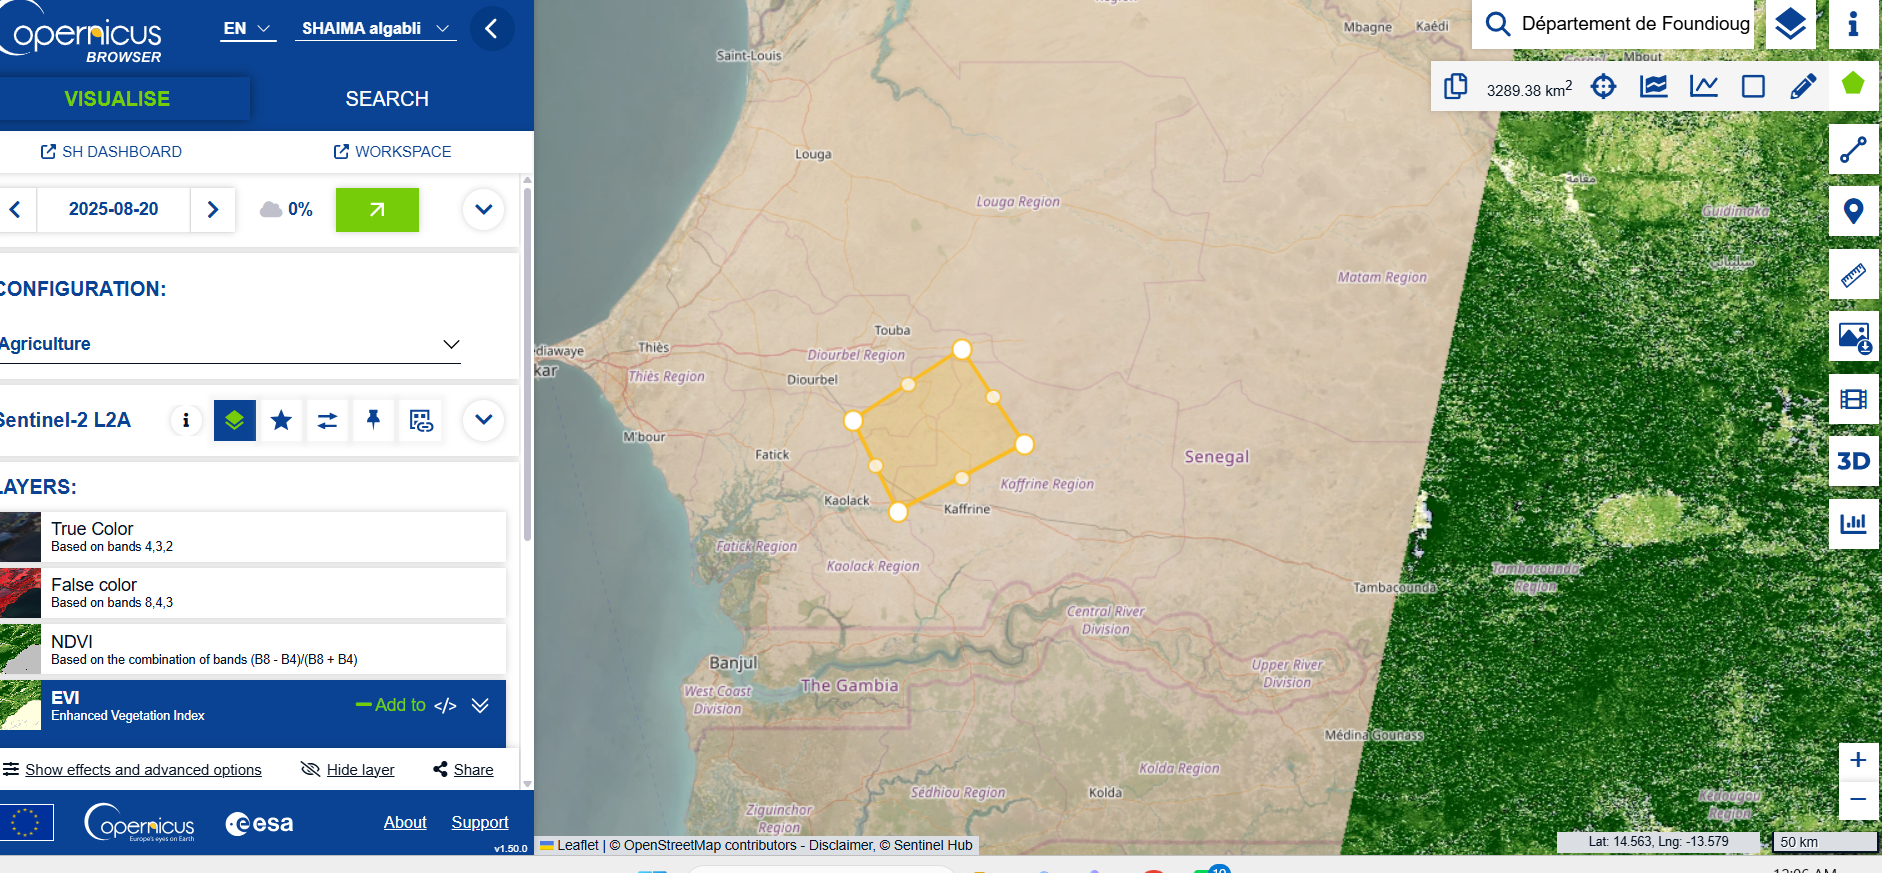

## Step 1 — Install and import libraries

We use **Rasterio** to read georeferenced TIFF rasters, **NumPy** for pixel-wise calculations, **Matplotlib** for NDVI maps, and **Pandas** for tabular summaries. The first cell installs Rasterio in Google Colab.

In [2]:
!pip -q install rasterio


In [3]:
import os
import re
import zipfile
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from collections import defaultdict

## Step 2 — Upload the Sentinel-2 data

Upload all required TIFF files at the same time.

For every acquisition date, the pipeline expects:

- one **B04** TIFF file
- one **B08** TIFF file
The code does not depend on month names such as May or August. It reads the acquisition date directly from the filename.

In [4]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(" -", filename)

Saving 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04_(Raw)-May - Copy.tiff to 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04_(Raw)-May - Copy (1).tiff
Saving 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04_(Raw)-May.tiff to 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04_(Raw)-May (1).tiff
Saving 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B08_(Raw)-May - Copy.tiff to 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B08_(Raw)-May - Copy (1).tiff
Saving 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B08_(Raw)-May.tiff to 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B08_(Raw)-May (1).tiff
Saving 2025-11-14-00_00_2025-11-14-23_59_Sentinel-2_L2A_B04_(Raw)-Nov.tiff to 2025-11-14-00_00_2025-11-14-23_59_Sentinel-2_L2A_B04_(Raw)-Nov (1).tiff
Saving 2025-11-14-00_00_2025-11-14-23_59_Sentinel-2_L2A_B08_(Raw)-Nov.tiff to 2025-11-14-00_00_2025-11-14-23_59_Sentinel-2_L2A_B08_(Raw)-Nov (1).tiff

Uploaded files:
 - 2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04

In [5]:
print("Uploaded files:")

for filename in uploaded.keys():
    print(filename)

Uploaded files:
2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04_(Raw)-May - Copy (1).tiff
2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04_(Raw)-May (1).tiff
2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B08_(Raw)-May - Copy (1).tiff
2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B08_(Raw)-May (1).tiff
2025-11-14-00_00_2025-11-14-23_59_Sentinel-2_L2A_B04_(Raw)-Nov (1).tiff
2025-11-14-00_00_2025-11-14-23_59_Sentinel-2_L2A_B08_(Raw)-Nov (1).tiff


In [6]:
uploaded_files = list(uploaded.keys())

data_files = defaultdict(dict)
duplicate_files = []

for filename in uploaded_files:
    date_match = re.search(r"\d{4}-\d{2}-\d{2}", filename)
    band_match = re.search(r"B04|B08", filename, re.IGNORECASE)

    if not date_match or not band_match:
        print(f"Skipped (date or B04/B08 not detected): {filename}")
        continue

    date = date_match.group()
    band = band_match.group().upper()
    path = os.path.join("/content", filename)

    if band in data_files[date]:
        duplicate_files.append((date, band, filename))
    else:
        data_files[date][band] = path

data_files = dict(sorted(data_files.items()))

print("\nDetected observations:")
for date, bands in data_files.items():
    print(f"\n{date}")
    print("  B04:", "Found" if "B04" in bands else "Missing")
    print("  B08:", "Found" if "B08" in bands else "Missing")

if duplicate_files:
    print("\nWARNING - duplicate band files detected:")
    for item in duplicate_files:
        print(item)



Detected observations:

2025-05-01
  B04: Found
  B08: Found

2025-11-14
  B04: Found
  B08: Found

WARNING - duplicate band files detected:
('2025-05-01', 'B04', '2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B04_(Raw)-May (1).tiff')
('2025-05-01', 'B08', '2025-05-01-00_00_2025-05-01-23_59_Sentinel-2_L2A_B08_(Raw)-May (1).tiff')


## 3. Validate the raster files

Before calculating NDVI, I check the input data rather than assuming that every downloaded TIFF is valid.

For each B04/B08 pair I inspect:

- image dimensions
- data type
- coordinate reference system (CRS)
- spatial transform
- minimum, maximum, and mean pixel values
- percentage of zero-valued pixels

B04 and B08 for the same date must have the same dimensions and spatial alignment. If they do not, pixel-by-pixel NDVI would compare different ground locations

In [7]:
valid_dates = {}

for date, bands in data_files.items():
    if "B04" in bands and "B08" in bands:
        valid_dates[date] = bands
    else:
        print(f"WARNING: {date} skipped because B04 or B08 is missing.")

print("\nNumber of complete observations:", len(valid_dates))

if len(valid_dates) == 0:
    raise ValueError("No complete B04/B08 date pairs were found.")



Number of complete observations: 2


In [8]:
validation_rows = []

for date, bands in valid_dates.items():

    with rasterio.open(bands["B04"]) as red_src, rasterio.open(bands["B08"]) as nir_src:
        red = red_src.read(1)
        nir = nir_src.read(1)

        same_shape = red_src.shape == nir_src.shape
        same_crs = red_src.crs == nir_src.crs
        same_transform = red_src.transform == nir_src.transform
        same_bounds = red_src.bounds == nir_src.bounds

        if not (same_shape and same_crs and same_transform and same_bounds):
            raise ValueError(
                f"Spatial mismatch between B04 and B08 for {date}. "
                "The two bands must be aligned before NDVI calculation."
            )

        validation_rows.append({
            "Date": date,
            "Shape": str(red.shape),
            "CRS": str(red_src.crs),
            "B04 Min": float(np.min(red)),
            "B04 Max": float(np.max(red)),
            "B04 Mean": float(np.mean(red)),
            "B04 Zero %": float(np.mean(red == 0) * 100),
            "B08 Min": float(np.min(nir)),
            "B08 Max": float(np.max(nir)),
            "B08 Mean": float(np.mean(nir)),
            "B08 Zero %": float(np.mean(nir == 0) * 100),
        })

validation_df = pd.DataFrame(validation_rows)
validation_df

,Date,Shape,CRS,B04 Min,B04 Max,B04 Mean,B04 Zero %,B08 Min,B08 Max,B08 Mean,B08 Zero %
0,2025-05-01,"(122, 118)",EPSG:4326,6737.0,24694.0,15197.613295,0.0,7445.0,29648.0,19213.409072,0.000000
1,2025-11-14,"(122, 118)",EPSG:4326,675.0,33030.0,8857.641498,0.0,0.0,37217.0,12876.658655,0.666852


## Step 4 — Check spatial consistency across dates

For a time-series or change-detection analysis, the observations should represent the same spatial grid.

This step checks every date against the first valid observation. If the grids are different, the code stops before producing a misleading pixel-by-pixel comparison.

In [9]:
dates = list(valid_dates.keys())
reference_date = dates[0]

with rasterio.open(valid_dates[reference_date]["B04"]) as ref_src:
    reference_shape = ref_src.shape
    reference_crs = ref_src.crs
    reference_transform = ref_src.transform
    reference_bounds = ref_src.bounds

for date in dates[1:]:
    with rasterio.open(valid_dates[date]["B04"]) as src:
        if (
            src.shape != reference_shape
            or src.crs != reference_crs
            or src.transform != reference_transform
            or src.bounds != reference_bounds
        ):
            raise ValueError(
                f"{date} is not spatially aligned with {reference_date}. "
                "Use the same AOI/grid or resample/reproject before change detection."
            )

print(f"All {len(dates)} observations use the same spatial grid.")


All 2 observations use the same spatial grid.


## 5. Calculate NDVI
For each valid pixel:

\[
NDVI = \frac{B08 - B04}{B08 + B04}
\]

The original TIFF values are stored as integers, but NDVI is a decimal quantity and can be negative. Therefore, both bands are converted to `float32` before calculation.

Pixels where either B04 or B08 equals zero are treated as invalid in this exercise and stored as `NaN`. Using `NaN` allows later statistics such as `np.nanmean()` to ignore invalid pixels automatically.

In [10]:
def calculate_ndvi(red_path, nir_path):

    with rasterio.open(red_path) as red_src:
        red = red_src.read(1).astype(np.float32)

    with rasterio.open(nir_path) as nir_src:
        nir = nir_src.read(1).astype(np.float32)

    valid = (red > 0) & (nir > 0)
    denominator = nir + red

    ndvi = np.full(red.shape, np.nan, dtype=np.float32)

    safe = valid & (denominator != 0)

    ndvi[safe] = (
        (nir[safe] - red[safe]) /
        denominator[safe]
    )

    return ndvi

## 6. Calculate NDVI automatically for every date

The same function is applied in a loop to every complete B04/B08 pair.  
No date-specific variables such as `ndvi_may` or `ndvi_Nov` are needed.


In [11]:
ndvi_results = {}

for date, bands in valid_dates.items():
    ndvi_results[date] = calculate_ndvi(
        bands["B04"],
        bands["B08"]
    )
    print(f"NDVI calculated for {date}")


NDVI calculated for 2025-05-01
NDVI calculated for 2025-11-14


## 7. Summarize NDVI for every observation

A single mean value is not enough to understand the whole image, so I report several statistics:

- **Mean**: average NDVI across valid pixels
- **Median**: central value and less sensitive to extreme values
- **Minimum / Maximum**: range of observed values
- **Valid Pixels (%)**: percentage of pixels actually used in the analysis

If mean and median behave differently, it can indicate that extreme values, water, bare soil, or other land-cover types are influencing the average

In [12]:
statistics = []

for date, ndvi in ndvi_results.items():

    valid_pixels = np.isfinite(ndvi)

    statistics.append({
        "Date": date,
        "Mean NDVI": float(np.nanmean(ndvi)),
        "Median NDVI": float(np.nanmedian(ndvi)),
        "Minimum NDVI": float(np.nanmin(ndvi)),
        "Maximum NDVI": float(np.nanmax(ndvi)),
        "Valid Pixels (%)": float(valid_pixels.mean() * 100)
    })

results_df = pd.DataFrame(statistics)
results_df["Date"] = pd.to_datetime(results_df["Date"])
results_df = results_df.sort_values("Date").reset_index(drop=True)

results_df

,Date,Mean NDVI,Median NDVI,Minimum NDVI,Maximum NDVI,Valid Pixels (%)
0,2025-05-01,0.121164,0.111515,-0.083331,0.346228,100.000000
1,2025-11-14,0.093583,0.143356,-0.993086,0.880606,99.333148


## 8. Visualize the NDVI map for every date

All maps use the same NDVI scale from `-1` to `1`.  
Keeping a common scale is important because otherwise each plot could use a different color range and make visual comparisons misleading.

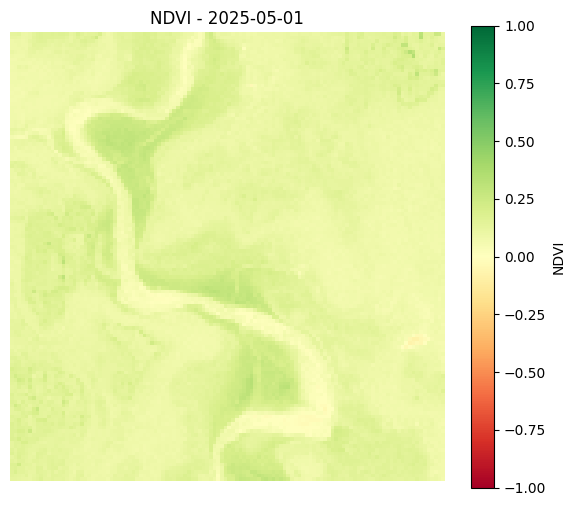

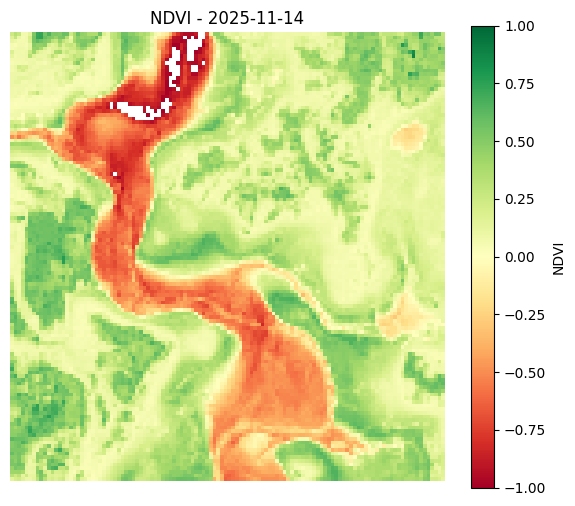

In [13]:
for date, ndvi in ndvi_results.items():

    plt.figure(figsize=(7, 6))

    plt.imshow(
        ndvi,
        cmap="RdYlGn",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(label="NDVI")
    plt.title(f"NDVI - {date}")
    plt.axis("off")
    plt.show()

## 9. Examine the NDVI distribution using percentiles

Minimum and maximum values can be strongly affected by a small number of unusual pixels.  
Percentiles help show where most of the NDVI values are located and make it easier to identify highly skewed distributions.


In [14]:
percentile_rows = []

for date, ndvi in ndvi_results.items():
    p = np.nanpercentile(ndvi, [1, 5, 25, 50, 75, 95, 99])

    percentile_rows.append({
        "Date": date,
        "P1": p[0],
        "P5": p[1],
        "P25": p[2],
        "P50 (Median)": p[3],
        "P75": p[4],
        "P95": p[5],
        "P99": p[6]
    })

percentiles_df = pd.DataFrame(percentile_rows)
percentiles_df["Date"] = pd.to_datetime(percentiles_df["Date"])
percentiles_df = percentiles_df.sort_values("Date").reset_index(drop=True)

percentiles_df

,Date,P1,P5,P25,P50 (Median),P75,P95,P99
0,2025-05-01,0.008838,0.054521,0.084338,0.111515,0.147764,0.232081,0.277349
1,2025-11-14,-0.849939,-0.629528,0.039418,0.143356,0.342007,0.542817,0.619727


## 10. Plot vegetation evolution through time

With two dates, this plot represents a before/after comparison.  
With three or more dates, it becomes a more informative vegetation time series.

I plot both mean and median NDVI because the median is less affected by extreme negative or positive pixels.


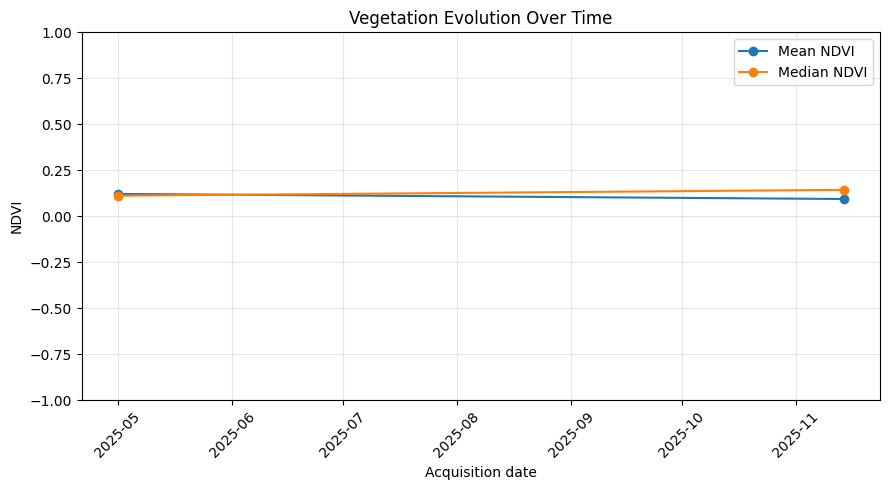

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    results_df["Date"],
    results_df["Mean NDVI"],
    marker="o",
    label="Mean NDVI"
)

plt.plot(
    results_df["Date"],
    results_df["Median NDVI"],
    marker="o",
    label="Median NDVI"
)

plt.xlabel("Acquisition date")
plt.ylabel("NDVI")
plt.title("Vegetation Evolution Over Time")
plt.ylim(-1, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Simple vegetation-focused summary

As an exploratory step, I also summarize pixels where `NDVI > 0`.

This can help reduce the influence of strongly negative pixels such as water, but it must **not** be interpreted as a formal crop classification. Positive NDVI can include many kinds of vegetation and some non-crop surfaces.


In [16]:
vegetation_rows = []

for date, ndvi in ndvi_results.items():

    valid = np.isfinite(ndvi)
    positive = valid & (ndvi > 0)

    if np.sum(positive) > 0:
        positive_mean = float(np.mean(ndvi[positive]))
        positive_median = float(np.median(ndvi[positive]))
    else:
        positive_mean = np.nan
        positive_median = np.nan

    vegetation_rows.append({
        "Date": date,
        "Positive NDVI Mean": positive_mean,
        "Positive NDVI Median": positive_median,
        "Positive NDVI Pixels": int(np.sum(positive)),
        "Positive NDVI Area (%)": float(np.sum(positive) / np.sum(valid) * 100)
    })

vegetation_df = pd.DataFrame(vegetation_rows)
vegetation_df["Date"] = pd.to_datetime(vegetation_df["Date"])
vegetation_df = vegetation_df.sort_values("Date").reset_index(drop=True)

vegetation_df


,Date,Positive NDVI Mean,Positive NDVI Median,Positive NDVI Pixels,Positive NDVI Area (%)
0,2025-05-01,0.121991,0.111871,14311,99.409558
1,2025-11-14,0.256766,0.224757,11072,77.426573


## 12. Change detection between the first and last observations

To show where vegetation conditions changed spatially, I calculate:

\[
\Delta NDVI = NDVI_{last} - NDVI_{first}
\]

- Positive values indicate an increase in NDVI.
- Negative values indicate a decrease in NDVI.
- Values near zero indicate little change.

Only pixels valid in both observations are compared.

In [17]:

sorted_dates = sorted(ndvi_results.keys())

if len(sorted_dates) >= 2:

    first_date = sorted_dates[0]
    last_date = sorted_dates[-1]

    first_ndvi = ndvi_results[first_date]
    last_ndvi = ndvi_results[last_date]

    common_valid = (
        np.isfinite(first_ndvi) &
        np.isfinite(last_ndvi)
    )

    ndvi_change = np.full(first_ndvi.shape, np.nan, dtype=np.float32)

    ndvi_change[common_valid] = (
        last_ndvi[common_valid] -
        first_ndvi[common_valid]
    )

    print("First observation:", first_date)
    print("Last observation :", last_date)
    print("Common valid pixels:", int(np.sum(common_valid)))
    print("Mean NDVI change:", float(np.nanmean(ndvi_change)))
    print("Median NDVI change:", float(np.nanmedian(ndvi_change)))

else:
    print("At least two observations are required for change detection.")


First observation: 2025-05-01
Last observation : 2025-11-14
Common valid pixels: 14300
Mean NDVI change: -0.02783350646495819
Median NDVI change: 0.048311565071344376


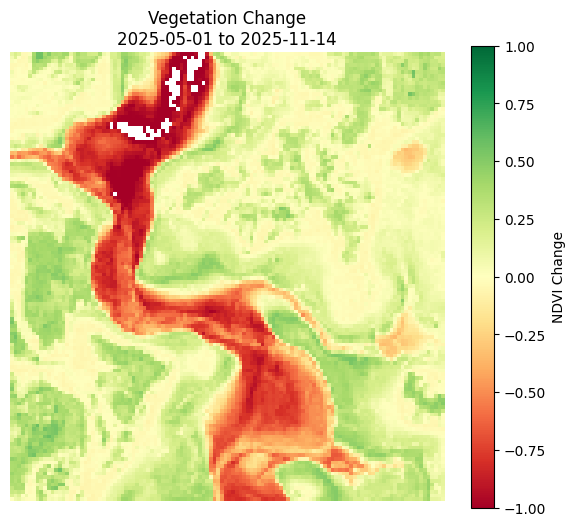

In [18]:

if len(sorted_dates) >= 2:

    plt.figure(figsize=(7, 6))

    plt.imshow(
        ndvi_change,
        cmap="RdYlGn",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(label="NDVI Change")
    plt.title(f"Vegetation Change\n{first_date} to {last_date}")
    plt.axis("off")
    plt.show()

## 13. Quantify the direction of change

The change map can also be summarized as the percentage of comparable pixels where NDVI increased or decreased.

A very small tolerance is used around zero so that tiny floating-point differences are not interpreted as meaningful change.

In [19]:

if len(sorted_dates) >= 2:

    changes = ndvi_change[common_valid]
    tolerance = 1e-6

    increased = np.sum(changes > tolerance)
    decreased = np.sum(changes < -tolerance)
    unchanged = np.sum(np.abs(changes) <= tolerance)
    total = len(changes)

    print(f"NDVI increased: {increased / total * 100:.2f}%")
    print(f"NDVI decreased: {decreased / total * 100:.2f}%")
    print(f"Approximately unchanged: {unchanged / total * 100:.2f}%")


NDVI increased: 60.42%
NDVI decreased: 39.58%
Approximately unchanged: 0.00%


## 14. Save the analysis results

The summary tables are saved as CSV files so the results can be reused outside the notebook.

The NDVI arrays for each date are also saved as georeferenced `float32` GeoTIFF files using the spatial metadata from the corresponding B04 image.


In [20]:

output_dir = "/content/ndvi_results"
os.makedirs(output_dir, exist_ok=True)

results_df.to_csv(
    os.path.join(output_dir, "ndvi_summary.csv"),
    index=False
)

percentiles_df.to_csv(
    os.path.join(output_dir, "ndvi_percentiles.csv"),
    index=False
)

vegetation_df.to_csv(
    os.path.join(output_dir, "positive_ndvi_summary.csv"),
    index=False
)

for date, ndvi in ndvi_results.items():

    reference_path = valid_dates[date]["B04"]

    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()

    profile.update(
        dtype="float32",
        count=1,
        nodata=np.nan
    )

    output_path = os.path.join(
        output_dir,
        f"NDVI_{date}.tif"
    )

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(ndvi.astype(np.float32), 1)

print("Results saved in:", output_dir)
print(os.listdir(output_dir))


Results saved in: /content/ndvi_results
['ndvi_summary.csv', 'ndvi_percentiles.csv', 'positive_ndvi_summary.csv', 'NDVI_2025-05-01.tif', 'NDVI_2025-11-14.tif']


## Conclusion

In this work, I developed a reusable Sentinel-2 NDVI pipeline to study vegetation change in a selected agricultural area in Senegal.

The analysis starts by automatically identifying the acquisition dates and matching the B04 (Red) and B08 (Near-Infrared) bands. Before calculating NDVI, the images are checked to make sure that they have the same spatial dimensions, coordinate system, extent, and alignment. Invalid pixels are excluded so that they do not affect the results.

NDVI is then calculated pixel by pixel for every valid observation. For each date, I summarize the vegetation condition using mean, median, minimum, maximum, percentiles, and the percentage of valid pixels. I also create NDVI maps using the same color scale so that the different dates can be compared visually.

When several dates are available, the pipeline plots the mean and median NDVI through time to show the overall vegetation evolution. In addition, the first and last observations are compared pixel by pixel to calculate the NDVI change map. This helps identify where vegetation greenness increased, decreased, or remained relatively stable.

An important finding from the analysis is that the mean NDVI alone may not always describe the vegetation condition correctly. Strongly negative pixels, for example from water or other non-vegetated surfaces, can reduce the mean value. For this reason, the median, percentiles, spatial NDVI maps, and change maps are considered together before drawing conclusions.

The pipeline is designed to work with different numbers of observations. With two dates, it provides a before-and-after vegetation comparison. With several dates, it can provide a more informative description of vegetation evolution over time.

This analysis is still an initial vegetation-monitoring approach. NDVI can indicate vegetation greenness, but it cannot by itself identify the crop type or explain the cause of vegetation change. A more complete agricultural monitoring system could include cloud masking, water masking, crop-specific masks, additional vegetation indices, climate information, and more observation dates.